# CNN + ImageDataGenerator: fashion_mnist

In [60]:
import astunparse
from sklearn.tree import plot_tree
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(0)
tf.random.set_seed(3)

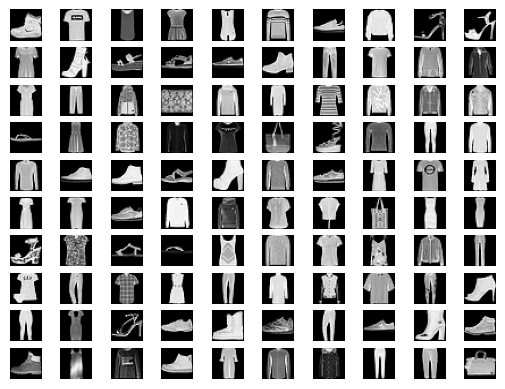

In [61]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255
# print(x_train[:2])
# print(y_train[:2])
y_train = to_categorical(y_train)
# print(y_train)
y_test = to_categorical(y_test)

# 이미지 시각화
plt.Figure(figsize=(10, 10))
for c in range(100):
    plt.subplot(10, 10, c+1)
    plt.axis('off')
    plt.imshow(x_train[c].reshape(28, 28), cmap='gray')
plt.show()


In [62]:
print(x_train.shape)    # 원본 자료 수(60000, 28, 28, 1)
print(y_train.shape)    # (60000, 10)

(60000, 28, 28, 1)
(60000, 10)


# 이미지 보강

In [63]:
'''
img_generate = ImageDataGenerator(
    rotation_range = 10,        # 랜덤하게 그림 회전(각도 0 ~ 180)
    zoom_range = 0.1,           # 확대, 축소
    shear_range = 0.5,          # 축을 중심으로 전환
    width_shift_range = 0.1,    # 수평 이동
    height_shift_range = 0.1,   # 수직 이동
    horizontal_flip = True,     # 좌우 수평 전화
    vertical_flip = False       # 상하 수직 전환
)

augument_size = 100     # 증상 샘플 수 100

idx = np.random.randint(x_train.shape[0], size=augument_size)
# print(idx)

x_src = x_train[idx].copy()
y_src = y_train[idx].copy()
# print(x_src)
# print(y_src)

gen = img_generate.flow(    # flow_from_directory
    x_src,
    y = np.zeros(augument_size),
    batch_size =  augument_size,
    shuffle = False,
    seed = 42
)

x_augumented = next(gen)[0]     #  flow 반환값은 제너레이터 객체이다. 그래서 next() 다음 배치를 꺼내옴
# 필요하면 원본에 합치기
x_train_aug = np.concatenate([x_train, x_augumented], axis=0)
y_trian_aug = np.concatenate([y_train, y_src], axis=0)
print(x_train_aug.shape)

# 확인용 시각화
n = 16
fig, axes = plt.subplots(1, n, figsize=(n, 4))
for i, ax in enumerate(axes):
    ax.imshow(x_augumented[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()
'''


"\nimg_generate = ImageDataGenerator(\n    rotation_range = 10,        # 랜덤하게 그림 회전(각도 0 ~ 180)\n    zoom_range = 0.1,           # 확대, 축소\n    shear_range = 0.5,          # 축을 중심으로 전환\n    width_shift_range = 0.1,    # 수평 이동\n    height_shift_range = 0.1,   # 수직 이동\n    horizontal_flip = True,     # 좌우 수평 전화\n    vertical_flip = False       # 상하 수직 전환\n)\n\naugument_size = 100     # 증상 샘플 수 100\n\nidx = np.random.randint(x_train.shape[0], size=augument_size)\n# print(idx)\n\nx_src = x_train[idx].copy()\ny_src = y_train[idx].copy()\n# print(x_src)\n# print(y_src)\n\ngen = img_generate.flow(    # flow_from_directory\n    x_src,\n    y = np.zeros(augument_size),\n    batch_size =  augument_size,\n    shuffle = False,\n    seed = 42\n)\n\nx_augumented = next(gen)[0]     #  flow 반환값은 제너레이터 객체이다. 그래서 next() 다음 배치를 꺼내옴\n# 필요하면 원본에 합치기\nx_train_aug = np.concatenate([x_train, x_augumented], axis=0)\ny_trian_aug = np.concatenate([y_train, y_src], axis=0)\nprint(x_train_aug.shape)\n\n# 확인용 시각화\nn

In [64]:
from pickle import FALSE

from matplotlib.pylab import rand


img_generate = ImageDataGenerator(
    rotation_range = 10,        # 랜덤하게 그림 회전(각도 0 ~ 180)
    zoom_range = 0.1,           # 확대, 축소
    shear_range = 0.2,          # 축을 중심으로 전환
    width_shift_range = 0.1,    # 수평 이동
    height_shift_range = 0.1,   # 수직 이동
    horizontal_flip = False,     # 좌우 수평 전화
    vertical_flip = False       # 상하 수직 전환
)

augument_size = 30000  
randidx = np.random.randint(x_train.shape[0], size=augument_size)
# print(randidx)

x_augument = x_train[randidx].copy()
y_augument = y_train[randidx].copy()

gen = img_generate.flow(    
    x_augument,
    y_augument,
    batch_size =  augument_size,
    shuffle = False,
    seed = 42
)

x_augument, y_augument = next(gen)

# 우너본에 합치기
x_train = np.concatenate([x_train, x_augument], axis = 0)
y_train = np.concatenate([y_train, y_augument], axis = 0)
print(x_train.shape)    # (90000, 28m, 28, 1)
print(y_train.shape)    # (90000, 10)


(90000, 28, 28, 1)
(90000, 10)


# CNN model

In [65]:
import keras
import tensorflow as tf

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(rate=0.1),

    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(rate=0.1),

    tf.keras.layers.Flatten(),

    # 분류기 레이어
    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(rate=0.3),
    
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(rate=0.3),

    tf.keras.layers.Dense(units=10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 dropout_8 (Dropout)         (None, 14, 14, 32)        0         
                                                                 
 conv2d_5 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 dropout_9 (Dropout)         (None, 7, 7, 64)         

# 모델 최적화 설정

In [ ]:
from tabnanny import verbose


MODEL_DIR = './mnist/'
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

modelpath = './mnist/{epoch:02d}-{val_loss:.2f}.keras'
chkpoint = ModelCheckpoint(filepath=modelpath, monitor='val_loss', save_best_only=True, verbose=2)

earlystop = EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(x_train, y_train, validation_split=0.2, epochs=100, \
                    batch_size=64, verbose=2, callbacks=[earlystop, chkpoint])
print('Test accuracy: %.4f'%(model.evaluate(x_test, y_test)[1]))

Epoch 1/100

Epoch 1: val_loss improved from inf to 0.55632, saving model to ./mnist\01-0.56.keras
1125/1125 - 4s - loss: 0.6147 - accuracy: 0.7741 - val_loss: 0.5563 - val_accuracy: 0.7861 - 4s/epoch - 3ms/step
Epoch 2/100

Epoch 2: val_loss improved from 0.55632 to 0.48536, saving model to ./mnist\02-0.49.keras
1125/1125 - 3s - loss: 0.3993 - accuracy: 0.8561 - val_loss: 0.4854 - val_accuracy: 0.8109 - 3s/epoch - 3ms/step
Epoch 3/100

Epoch 3: val_loss improved from 0.48536 to 0.45031, saving model to ./mnist\03-0.45.keras
1125/1125 - 3s - loss: 0.3452 - accuracy: 0.8760 - val_loss: 0.4503 - val_accuracy: 0.8270 - 3s/epoch - 3ms/step
Epoch 4/100

Epoch 4: val_loss improved from 0.45031 to 0.41002, saving model to ./mnist\04-0.41.keras
1125/1125 - 3s - loss: 0.3119 - accuracy: 0.8868 - val_loss: 0.4100 - val_accuracy: 0.8473 - 3s/epoch - 3ms/step
Epoch 5/100

Epoch 5: val_loss improved from 0.41002 to 0.39583, saving model to ./mnist\05-0.40.keras
1125/1125 - 3s - loss: 0.2894 - accur

# 시각화

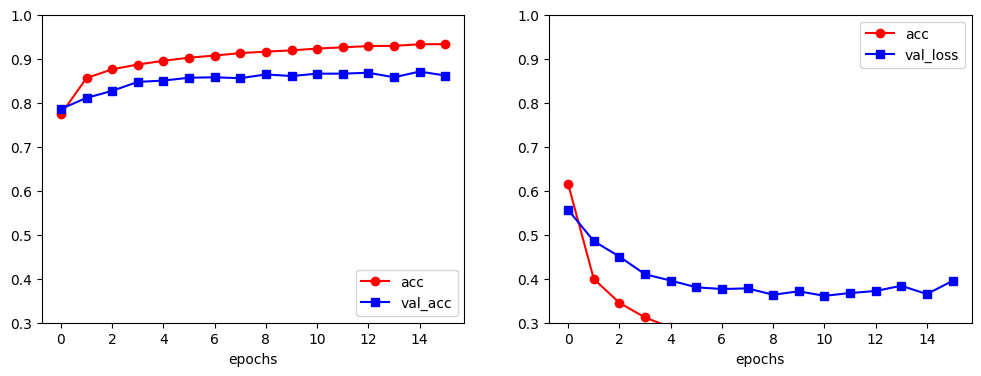

In [68]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], marker='o', c='red', label='acc')
plt.plot(history.history['val_accuracy'], marker='s', c='blue', label='val_acc')
plt.xlabel('epochs')
plt.ylim(0.3, 1)
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], marker='o', c='red', label='acc')
plt.plot(history.history['val_loss'], marker='s', c='blue', label='val_loss')
plt.xlabel('epochs')
plt.ylim(0.3, 1)
plt.legend(loc='upper right')
plt.show()
plt.close()